In [47]:
!pip install statsmodels --upgrade

Requirement already up-to-date: statsmodels in /usr/local/lib/python3.6/dist-packages (0.12.0)


In [48]:
from pandas import read_csv
from matplotlib import pyplot
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf
from pandas import DataFrame
from pandas import concat
from matplotlib import pyplot
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from math import sqrt
import numpy as np
import pandas as pd
import csv

In [49]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [50]:
array = np.load('/content/gdrive/My Drive/Colab Notebooks/Tdobs.npy', allow_pickle=True)

In [51]:
list1 = []
for element in array:
  list1.append(element)
print(list1)

[0.0, 0.0, 0.0, 0.0, -0.33333333333333337, -1.0, -1.0, -1.6666666666666665, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -2.0, -2.0, -2.0, -1.6666666666666665, -1.0, -0.6666666666666666, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33333333333333337, 2.6666666666666665, 2.0, 0.6666666666666666, -1.3333333333333335, -2.0, -2.0, -1.6666666666666665, -1.0, -1.3333333333333335, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.3333333333333335, -3.6666666666666665, -4.0, -4.0, -4.0, -4.0, -4.0, -3.6666666666666665, -3.0, -3.0, -3.0, -4.0, -4.333333333333333, -4.333333333333333, -4.666666666666667, -4.0, -4.0, -4.666666666666667, -4.666666666666667, -5.666666666666667, -5.0, -6.0, -6.666666666666667, -6.333333333333333, -6.333333333333333, -7.333333333333333, -7.333333333333333, -7.666666666666667, -7.0, -7.0, -7.0, -6.666666666666667, -5.0, -4.0, -2.6666666666666665, -2.6666666666666665, -1.6666666666666665, -2.3333333333333335, -3.0, -3.3333333333333335, -4.0, -4.333333333333333, -3.6666666666666665, -3.3333333333333335,

In [52]:
series = pd.Series(list1)

In [53]:
print(series)

0        0.000000
1        0.000000
2        0.000000
3        0.000000
4       -0.333333
           ...   
26996   -4.000000
26997   -4.000000
26998   -4.000000
26999   -4.000000
27000   -3.000000
Length: 27001, dtype: float64


0    0.000000
1    0.000000
2    0.000000
3    0.000000
4   -0.333333
dtype: float64


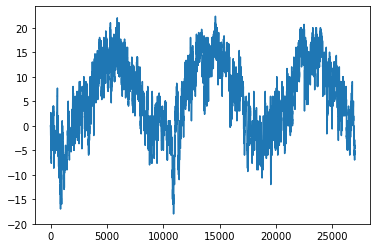

In [54]:
print(series.head())
series.plot()
pyplot.show()

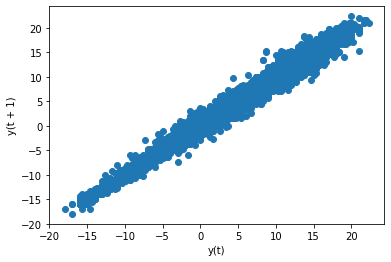

In [55]:
lag_plot(series)
pyplot.show()

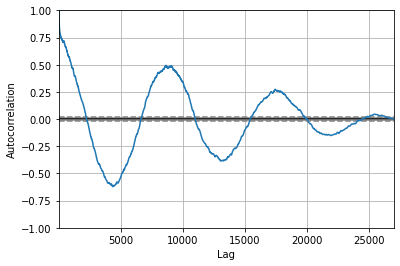

In [56]:
autocorrelation_plot(series)
pyplot.show()

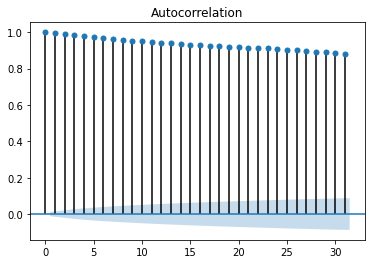

In [57]:
plot_acf(series, lags=31)
pyplot.show()

In [58]:
# create lagged dataset
values = DataFrame(series.values)
dataframe = concat([values.shift(1), values], axis=1)
dataframe.columns = ['t-1', 't+1']
# split into train and test sets
X = dataframe.values
train, test = X[1:len(X)-7], X[len(X)-7:]
train_X, train_y = train[:,0], train[:,1]
test_X, test_y = test[:,0], test[:,1]

Test MSE: 0.143


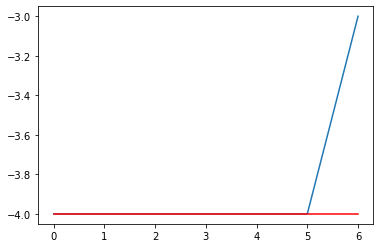

In [59]:
# persistence model
def model_persistence(x):
	return x
 
# walk-forward validation
predictions = list()
for x in test_X:
	yhat = model_persistence(x)
	predictions.append(yhat)
test_score = mean_squared_error(test_y, predictions)
print('Test MSE: %.3f' % test_score)
# plot predictions vs expected
pyplot.plot(test_y)
pyplot.plot(predictions, color='red')
pyplot.show()

In [60]:
# split dataset
X = series.values
train, test = X[1:len(X)-7], X[len(X)-7:]

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,


Coefficients: [ 2.45941612e-02  1.05896510e+00 -5.23608340e-02 -1.17585484e-02
 -1.37836299e-02 -2.17344853e-02  4.94032751e-03  4.88300142e-03
  1.34006217e-02 -7.80640831e-03  9.51588356e-03 -8.86727413e-03
  1.79848927e-02 -1.08934125e-02  2.53399248e-03 -1.72621074e-02
  2.72746081e-02 -2.13355805e-02  7.81046354e-03 -4.70031466e-04
  5.80344074e-03  2.03121238e-03  8.27390884e-03  4.17527384e-02
 -7.85079818e-04 -9.66693719e-03 -2.21730930e-02 -1.85753826e-02
 -9.87101780e-03  1.79988548e-02]
predicted=-3.971556, expected=-4.000000
predicted=-3.977213, expected=-4.000000
predicted=-3.986044, expected=-4.000000
predicted=-3.979518, expected=-4.000000
predicted=-3.931213, expected=-4.000000
predicted=-3.861915, expected=-4.000000
predicted=-3.797722, expected=-3.000000
Test RMSE: 0.308


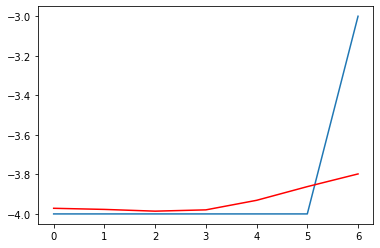

In [61]:
# train autoregression
model = AutoReg(train, lags=29)
model_fit = model.fit()
print('Coefficients: %s' % model_fit.params)
# make predictions
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)
for i in range(len(predictions)):
	print('predicted=%f, expected=%f' % (predictions[i], test[i]))
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot results
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,


predicted=-3.971556, expected=-4.000000
predicted=-4.007335, expected=-4.000000
predicted=-4.008685, expected=-4.000000
predicted=-3.992769, expected=-4.000000
predicted=-3.951512, expected=-4.000000
predicted=-3.932589, expected=-4.000000
predicted=-3.939560, expected=-3.000000
Test RMSE: 0.357


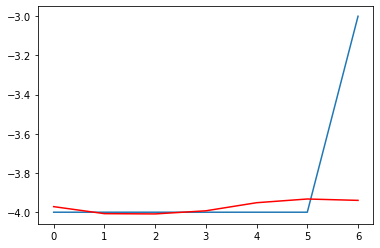

In [62]:
# split dataset
X = series.values
train, test = X[1:len(X)-7], X[len(X)-7:]
# train autoregression
window = 29
model = AutoReg(train, lags=29)
model_fit = model.fit()
coef = model_fit.params
# walk forward over time steps in test
history = train[len(train)-window:]
history = [history[i] for i in range(len(history))]
predictions = list()
for t in range(len(test)):
	length = len(history)
	lag = [history[i] for i in range(length-window,length)]
	yhat = coef[0]
	for d in range(window):
		yhat += coef[d+1] * lag[window-d-1]
	obs = test[t]
	predictions.append(yhat)
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()